<a href="https://colab.research.google.com/github/DavidMazurencuPele/DA-Methods-Investigation/blob/main/lab3%264_exercises_round2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Neural Networks: An Introduction
## Faculty of Physics — Robotics Group

Welcome! In this notebook you will build neural networks **from scratch**, one step at a time.

| Exercise nb. | Topic |
|---|-------|
| 1 | Linear regression — single perceptron, identity activation |
| 2 | Binary classification — single perceptron, sigmoid |
| 3 | Non-linear regression — hidden layer, **manual backprop** |
| 4 | Non-linear regression — same problem with **PyTorch** |
| 5 | Non-linear regression — **effect of depth** on accuracy |
| 6 | Multi-class classification — **PyTorch** |
| 7 | Multi-class classification — **effect of depth** on boundaries & stability |

> **How to use this notebook:** Each exercise states the problem and gives you hints and
> derivations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim

# Fix random seeds so every run gives the same results
np.random.seed(42)
torch.manual_seed(42)

print("All imports successful.")

All imports successful.


---
## Exercise 1 — IR Sensor Calibration (Linear Regression)

### Background
Many robots use infrared (IR) sensors to estimate distance. The sensor outputs a voltage,
but we need the actual distance in centimetres. For short-range IR sensors this relationship
is approximately **linear**:

$$\text{distance} = w \cdot \text{voltage} + b + \varepsilon$$

where $\varepsilon$ is measurement noise. Your task: learn $w$ and $b$ from 500 calibration
measurements.

We simulate data with $w = 2$, $b = 1$, and Gaussian noise $\varepsilon \sim \mathcal{N}(0, 0.3^2)$.

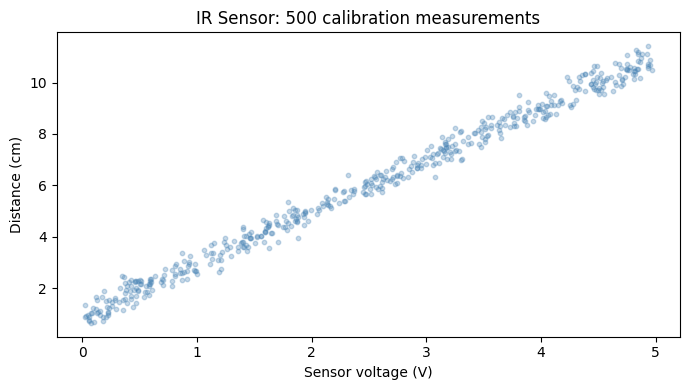

In [2]:
N = 500
x1 = np.random.uniform(0, 5, N)
eps1 = np.random.normal(0, 0.3, N)
y1 = 2 * x1 + 1 + eps1

plt.figure(figsize=(7, 4))
plt.scatter(x1, y1, alpha=0.3, s=10, color='steelblue')
plt.xlabel("Sensor voltage (V)")
plt.ylabel("Distance (cm)")
plt.title("IR Sensor: 500 calibration measurements")
plt.tight_layout()
plt.show()

### Your Task

Implement a **single perceptron with identity activation** that learns the calibration
mapping via gradient descent on mini-batches.

The perceptron computes: $\hat{y} = w \cdot x + b$

Loss — **Mean Squared Error (MSE)**:
$$\mathcal{L} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$

**Step-by-step hints:**

1. **Split** `x1, y1` into train (80%) and validation (20%).  
   Use `np.random.permutation(N)` to get a shuffled index array, then slice.

2. **Initialise** $w$ and $b$ with `np.random.randn()`.

3. **Mini-batch loop:** For each epoch, shuffle the training set, then iterate in chunks
   of `batch_size = 32`. For each batch:
   - Forward: $\hat{y} = w \cdot x_{\text{batch}} + b$
   - Compute MSE loss
   - Gradients (derive from the chain rule — result below for reference):
     $$\frac{\partial \mathcal{L}}{\partial w} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)\, x_i, \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{2}{n}\sum_i (\hat{y}_i - y_i)$$
   - Update: $w \leftarrow w - \eta \cdot \nabla_w$, same for $b$ (use $\eta = 0.01$)

4. After each epoch compute the validation MSE (no update).

5. **Plot** train and val loss over epochs, then plot the learned line over the data.

6. Print the learned $w$ and $b$ and compare with the true values 2 and 1.

In [3]:
### SOLUTION — split and initialise

split1 = int(0.8 * N)
idx1 = np.random.permutation(N)
x1_train, x1_val = x1[idx1[:split1]], x1[idx1[split1:]]
y1_train, y1_val = y1[idx1[:split1]], y1[idx1[split1:]]

print(f"Train: {len(x1_train)} samples   Val: {len(x1_val)} samples")

w1 = np.random.randn()
b1 = np.random.randn()
print(f"Initial  w={w1:.4f}  b={b1:.4f}")

Train: 400 samples   Val: 100 samples
Initial  w=1.0636  b=2.2461


In [4]:
### SOLUTION — training loop

lr1 = 0.01
epochs1 = 100
batch_size1 = 32

train_losses1 = []
val_losses1 = []

for epoch in range(epochs1):
    # Shuffle training data
    perm = np.random.permutation(len(x1_train))
    xt = x1_train[perm]
    yt = y1_train[perm]

    batch_ls = []
    for i in range(0, len(xt), batch_size1):
        xb = xt[i : i + batch_size1]
        yb = yt[i : i + batch_size1]

        # Forward pass (identity activation)
        y_hat = w1 * xb + b1

        # MSE loss on this batch
        loss = np.mean((y_hat - yb) ** 2)
        batch_ls.append(loss)

        # Gradients
        err = y_hat - yb
        dw = 2 * np.mean(err * xb)
        db = 2 * np.mean(err)

        # Gradient descent update
        w1 -= lr1 * dw
        b1 -= lr1 * db

    train_losses1.append(np.mean(batch_ls))

    # Validation (evaluate only, no update)
    val_hat = w1 * x1_val + b1
    val_losses1.append(np.mean((val_hat - y1_val) ** 2))

print(f"Learned  w={w1:.4f}  b={b1:.4f}")
print(f"True     w=2.0000  b=1.0000")

Learned  w=2.0241  b=0.9622
True     w=2.0000  b=1.0000


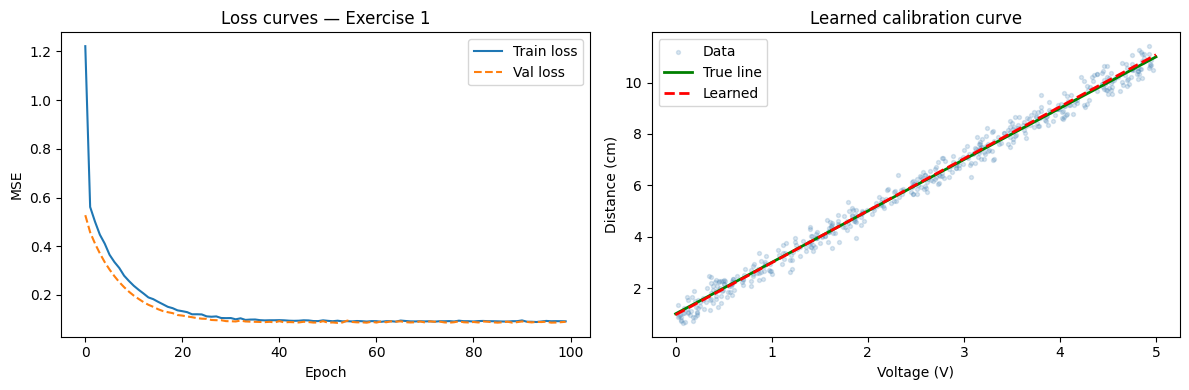

In [5]:
### SOLUTION — plots

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses1, label="Train loss")
plt.plot(val_losses1, label="Val loss", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss curves — Exercise 1")
plt.legend()

plt.subplot(1, 2, 2)
x_line = np.linspace(0, 5, 100)
plt.scatter(x1, y1, alpha=0.2, s=8, color='steelblue', label="Data")
plt.plot(x_line, 2 * x_line + 1, color='green', linewidth=2, label="True line")
plt.plot(x_line, w1 * x_line + b1, color='red', linewidth=2, linestyle='--', label="Learned")
plt.xlabel("Voltage (V)")
plt.ylabel("Distance (cm)")
plt.title("Learned calibration curve")
plt.legend()

plt.tight_layout()
plt.show()

---
## Exercise 2 — Obstacle Detection (Binary Classification)

### Background
A wheeled robot carries two forward-facing distance sensors (left and right).
We want to classify each pair of readings as:
- **Safe (0):** Both sensors read large distances — path is clear
- **Obstacle (1):** Close object detected

The two classes are linearly separable with some noise. We model this as two Gaussian
clusters: safe readings cluster around $(2.7, 2.7)$ and obstacle readings around $(1.5, 1.5)$.

### Model
A perceptron for binary classification uses the **sigmoid** activation for smooth,
gradient-friendly training:
$$\sigma(z) = \frac{1}{1+e^{-z}}, \qquad \hat{y} = \sigma(\mathbf{w}\cdot\mathbf{x} + b)$$

Loss — **Binary Cross-Entropy**:
$$\mathcal{L} = -\frac{1}{n}\sum_i\bigl[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\bigr]$$

The gradients are remarkably clean for this loss + activation combination:
$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{n}\, X^T (\hat{y} - y), \qquad \frac{\partial \mathcal{L}}{\partial b} = \frac{1}{n}\sum_i(\hat{y}_i - y_i)$$

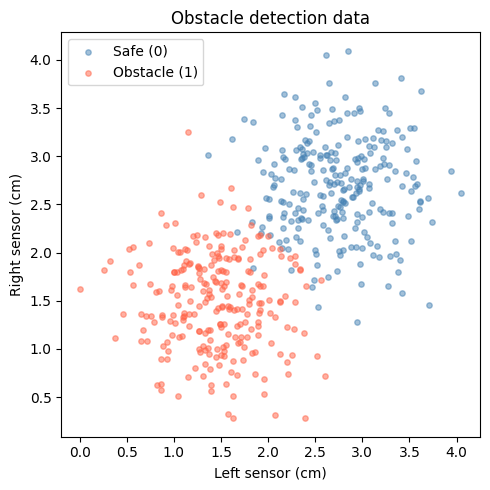

In [6]:
n_per_class = 250

x2_c0 = np.random.randn(n_per_class, 2) * 0.5 + np.array([2.7, 2.7])   # safe
x2_c1 = np.random.randn(n_per_class, 2) * 0.5 + np.array([1.5, 1.5])   # obstacle

X2 = np.vstack([x2_c0, x2_c1])
Y2 = np.array([0] * n_per_class + [1] * n_per_class, dtype=float)

plt.figure(figsize=(5, 5))
plt.scatter(x2_c0[:, 0], x2_c0[:, 1], alpha=0.5, s=15, color='steelblue', label="Safe (0)")
plt.scatter(x2_c1[:, 0], x2_c1[:, 1], alpha=0.5, s=15, color='tomato',    label="Obstacle (1)")
plt.xlabel("Left sensor (cm)")
plt.ylabel("Right sensor (cm)")
plt.title("Obstacle detection data")
plt.legend()
plt.tight_layout()
plt.show()

### Your Task

1. **Split** `X2, Y2` into train/val (80/20).

2. **Initialise** weight vector $\mathbf{w}$ (shape `(2,)`) and scalar $b$ randomly.

3. **Training loop** — same mini-batch structure as Exercise 1:
   - Forward: $z = X_{\text{batch}} \cdot \mathbf{w} + b$, then $\hat{y} = \sigma(z)$
   - BCE loss
   - Gradients (see formulas above)
   - Update

4. **Accuracy:** Classify by thresholding $\hat{y} > 0.5$. Report train and val accuracy.

5. **Compare** with `sklearn`'s `Perceptron`. Does it find a similar boundary?

6. **Plot both decision boundaries** side by side using a meshgrid:
   ```python
   xx, yy = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
   grid   = np.c_[xx.ravel(), yy.ravel()]
   Z = ...  # classify grid points, then .reshape(xx.shape)
   plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
   ```

In [7]:
### SOLUTION — split, initialise, train

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

split2 = int(0.8 * len(X2))
idx2 = np.random.permutation(len(X2))
X2_train, X2_val = X2[idx2[:split2]], X2[idx2[split2:]]
Y2_train, Y2_val = Y2[idx2[:split2]], Y2[idx2[split2:]]

w2 = np.random.randn(2)
b2 = np.random.randn()

lr2 = 0.1
epochs2 = 200
batch_size2 = 32
eps_log = 1e-8

train_losses2, val_losses2 = [], []

for epoch in range(epochs2):
    perm = np.random.permutation(len(X2_train))
    Xt = X2_train[perm]
    Yt = Y2_train[perm]

    bl = []
    for i in range(0, len(Xt), batch_size2):
        Xb = Xt[i : i + batch_size2]
        Yb = Yt[i : i + batch_size2]

        y_hat = sigmoid(Xb @ w2 + b2)
        loss = -np.mean(Yb * np.log(y_hat + eps_log) + (1 - Yb) * np.log(1 - y_hat + eps_log))
        bl.append(loss)

        err = y_hat - Yb
        dw = Xb.T @ err / len(Yb)
        db = np.mean(err)

        w2 -= lr2 * dw
        b2 -= lr2 * db

    train_losses2.append(np.mean(bl))

    val_hat = sigmoid(X2_val @ w2 + b2)
    val_loss = -np.mean(Y2_val * np.log(val_hat + eps_log) + (1 - Y2_val) * np.log(1 - val_hat + eps_log))
    val_losses2.append(val_loss)

train_acc2 = np.mean((sigmoid(X2_train @ w2 + b2) > 0.5) == Y2_train)
val_acc2   = np.mean((sigmoid(X2_val   @ w2 + b2) > 0.5) == Y2_val)
print(f"Our implementation  — Train: {train_acc2*100:.1f}%   Val: {val_acc2*100:.1f}%")

Our implementation  — Train: 95.8%   Val: 100.0%


In [8]:
### SOLUTION — sklearn comparison

sk_perc = SklearnPerceptron(max_iter=1000, random_state=42)
sk_perc.fit(X2_train, Y2_train)

sk_train_acc = sk_perc.score(X2_train, Y2_train)
sk_val_acc   = sk_perc.score(X2_val,   Y2_val)
print(f"sklearn Perceptron  — Train: {sk_train_acc*100:.1f}%   Val: {sk_val_acc*100:.1f}%")
print()
print(f"Our weights:     {w2}   bias: {b2:.4f}")
print(f"sklearn weights: {sk_perc.coef_[0]}   bias: {sk_perc.intercept_[0]:.4f}")
print()
print("Note: sklearn's Perceptron uses the hard step function + perceptron update rule,")
print("while ours uses sigmoid + BCE gradient descent. Both find a separating boundary,")
print("but the exact weights can differ — what matters is the decision boundary.")

sklearn Perceptron  — Train: 93.5%   Val: 98.0%

Our weights:     [-2.42265222 -1.95564697]   bias: 8.9524
sklearn weights: [-11.82622998  -7.90940572]   bias: 45.0000

Note: sklearn's Perceptron uses the hard step function + perceptron update rule,
while ours uses sigmoid + BCE gradient descent. Both find a separating boundary,
but the exact weights can differ — what matters is the decision boundary.


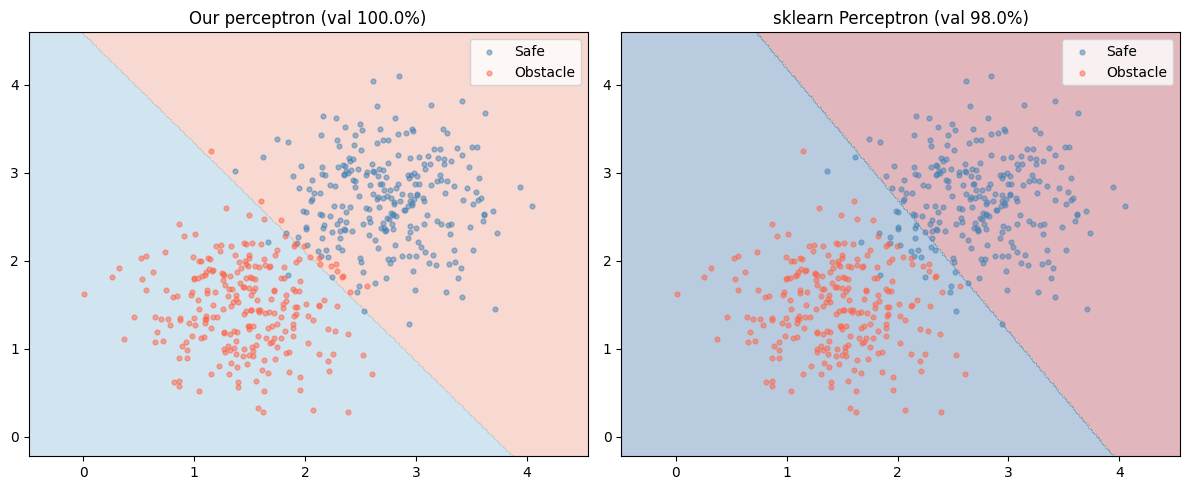

In [9]:
### SOLUTION — decision boundary plots

xmin2 = X2[:, 0].min() - 0.5
xmax2 = X2[:, 0].max() + 0.5
ymin2 = X2[:, 1].min() - 0.5
ymax2 = X2[:, 1].max() + 0.5

xx2, yy2 = np.meshgrid(np.linspace(xmin2, xmax2, 300),
                        np.linspace(ymin2, ymax2, 300))
grid2 = np.c_[xx2.ravel(), yy2.ravel()]

Z_ours = (sigmoid(grid2 @ w2 + b2) > 0.5).reshape(xx2.shape)
Z_sk   = sk_perc.predict(grid2).reshape(xx2.shape)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.contourf(xx2, yy2, Z_ours, alpha=0.3, cmap='RdBu')
plt.scatter(X2[Y2 == 0, 0], X2[Y2 == 0, 1], s=12, alpha=0.5, color='steelblue', label="Safe")
plt.scatter(X2[Y2 == 1, 0], X2[Y2 == 1, 1], s=12, alpha=0.5, color='tomato',    label="Obstacle")
plt.title(f"Our perceptron (val {val_acc2*100:.1f}%)")
plt.legend()

plt.subplot(1, 2, 2)
plt.contourf(xx2, yy2, Z_sk, alpha=0.3, cmap='RdBu')
plt.scatter(X2[Y2 == 0, 0], X2[Y2 == 0, 1], s=12, alpha=0.5, color='steelblue', label="Safe")
plt.scatter(X2[Y2 == 1, 0], X2[Y2 == 1, 1], s=12, alpha=0.5, color='tomato',    label="Obstacle")
plt.title(f"sklearn Perceptron (val {sk_val_acc*100:.1f}%)")
plt.legend()

plt.tight_layout()
plt.show()

---
## Exercise 3 — Parabolic Trajectory Prediction (Manual Backpropagation)

### Background
A robot arm launches a ball. The relationship between launch speed $x$ (m/s) and
maximum height $y$ (m) follows a **quadratic** law:
$$y = x^2 + \varepsilon$$

A single perceptron **cannot** learn this — a linear combination of inputs can only
produce a hyperplane. We need a **hidden layer** with a **non-linear activation**.

### Network Architecture ($1 \to H \to 1$)
$$x \;\xrightarrow{W_1, \mathbf{b}_1}\; \mathbf{h} = W_1 x + \mathbf{b}_1 \;\xrightarrow{\text{ReLU}}\; \hat{\mathbf{h}} = \max(\mathbf{h}, 0) \;\xrightarrow{\mathbf{w}_2, b_2}\; \hat{y} = \mathbf{w}_2 \cdot \hat{\mathbf{h}} + b_2$$

Dimensions: $W_1 \in \mathbb{R}^{H\times 1}$, $\mathbf{b}_1 \in \mathbb{R}^H$, $\mathbf{w}_2 \in \mathbb{R}^H$, $b_2 \in \mathbb{R}$.

### ReLU and Its Derivative
$$\text{ReLU}(z) = \max(0, z), \qquad \text{ReLU}'(z) = \begin{cases}1 & z > 0 \\ 0 & z \leq 0\end{cases}$$

> **Issue at $z = 0$:** ReLU is not differentiable there. In practice we set the
> subgradient to 0 at that point — it almost never matters because hitting *exactly*
> 0.0 in floating point is extremely rare.
>
> **Dying ReLU problem:** If a neuron's pre-activation is always negative, it outputs 0
> forever and receives zero gradient — it is "dead". **Leaky ReLU** fixes this by using
> a small slope $\alpha \approx 0.01$ for $z < 0$: $\text{LReLU}(z) = \max(\alpha z, z)$.

### Backpropagation (batch formulas)

Loss: $\mathcal{L} = \frac{1}{B}\|\hat{y} - y\|^2$.  Let $B$ = batch size.

1. $\boldsymbol{\delta}_{\text{out}} = \frac{2}{B}(\hat{y} - y) \in \mathbb{R}^B$

2. $\dfrac{\partial \mathcal{L}}{\partial \mathbf{w}_2} = \hat{H}^T \boldsymbol{\delta}_{\text{out}} \in \mathbb{R}^H$,
   $\quad \dfrac{\partial \mathcal{L}}{\partial b_2} = \sum_i \delta_{\text{out},i}$

3. $\boldsymbol{\delta}_h = (\boldsymbol{\delta}_{\text{out}} \otimes \mathbf{w}_2) \odot \text{ReLU}'(H) \in \mathbb{R}^{B\times H}$  
   where $\otimes$ is the outer product giving shape $(B, H)$.

4. $\dfrac{\partial \mathcal{L}}{\partial W_1} = \boldsymbol{\delta}_h^T X_b \in \mathbb{R}^{H\times 1}$,
   $\quad \dfrac{\partial \mathcal{L}}{\partial \mathbf{b}_1} = \sum_{\text{batch}} \boldsymbol{\delta}_h \in \mathbb{R}^H$

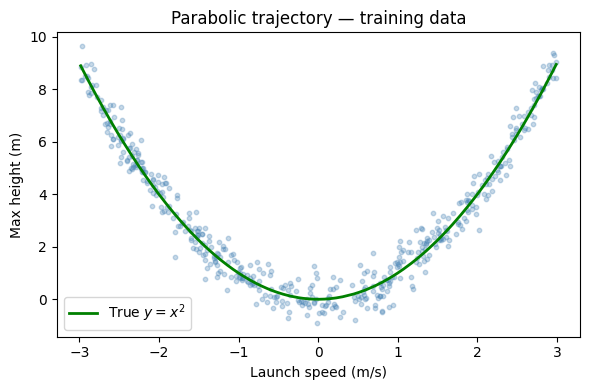

In [10]:
N3 = 500
x3 = np.random.uniform(-3, 3, N3)
eps3 = np.random.normal(0, 0.5, N3)
y3 = x3 ** 2 + eps3

sort_idx = np.argsort(x3)

plt.figure(figsize=(6, 4))
plt.scatter(x3, y3, alpha=0.3, s=10, color='steelblue')
plt.plot(x3[sort_idx], x3[sort_idx]**2, color='green', linewidth=2, label="True $y=x^2$")
plt.xlabel("Launch speed (m/s)")
plt.ylabel("Max height (m)")
plt.title("Parabolic trajectory — training data")
plt.legend()
plt.tight_layout()
plt.show()

### Your Task

1. **Split** `x3, y3` into train/val (80/20).

2. **Initialise** the parameters. Scale `np.random.randn()` by a small constant (e.g. 0.1)
   to avoid saturated activations at the start. Set biases to zero.

3. **Forward pass:** Given a batch `x_b` of shape `(B, 1)`:  
   `h_pre = x_b @ W1.T + b1`  → shape `(B, H)`  
   `h_post = relu(h_pre)`     → shape `(B, H)`  
   `y_hat = h_post @ w2 + b2` → shape `(B,)`

4. **Backward pass:** Use the formulas above. Cache `x_b, h_pre, h_post` during the
   forward pass — you'll need them for the backward pass.

5. **Train** for 500 epochs with `batch_size = 32`, `lr = 0.01`, starting with $H = 8$.
   Plot loss curves and the predicted curve against data.

6. **Experiment with hidden layer size:** Try $H \in \{1, 2, 4, 8, 16, 32\}$.
   Can a single neuron ($H=1$) approximate $x^2$? At what $H$ does the fit
   become visually indistinguishable from the true parabola?

In [11]:
### SOLUTION — activations, forward, backward

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    """Subgradient: 1 where z > 0, 0 elsewhere."""
    return (z > 0).astype(float)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_grad(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)


def init_network3(H, scale=0.1):
    W1 = np.random.randn(H, 1) * scale
    b1 = np.zeros(H)
    w2 = np.random.randn(H) * scale
    b2 = 0.0
    return W1, b1, w2, b2


def forward3(x_b, W1, b1, w2, b2):
    """
    x_b : (B, 1)
    returns y_hat (B,) and cache needed for backward
    """
    h_pre  = x_b @ W1.T + b1    # (B, H)
    h_post = relu(h_pre)         # (B, H)
    y_hat  = h_post @ w2 + b2   # (B,)
    return y_hat, (x_b, h_pre, h_post)


def backward3(y_hat, y_b, cache, w2):
    """
    Returns gradients: dW1 (H,1), db1 (H,), dw2 (H,), db2 scalar
    """
    x_b, h_pre, h_post = cache
    B = len(y_b)

    # Gradient at output
    d_out = 2 * (y_hat - y_b) / B          # (B,)

    # Gradients of output layer parameters
    dw2  = h_post.T @ d_out                 # (H,)
    db2  = np.sum(d_out)                    # scalar

    # Backprop through ReLU
    d_h_post = np.outer(d_out, w2)          # (B, H)
    d_h_pre  = d_h_post * relu_grad(h_pre)  # (B, H)

    # Gradients of hidden layer parameters
    dW1 = d_h_pre.T @ x_b                  # (H, 1)
    db1 = d_h_pre.sum(axis=0)              # (H,)

    return dW1, db1, dw2, db2

H=8  final val MSE: 0.2979


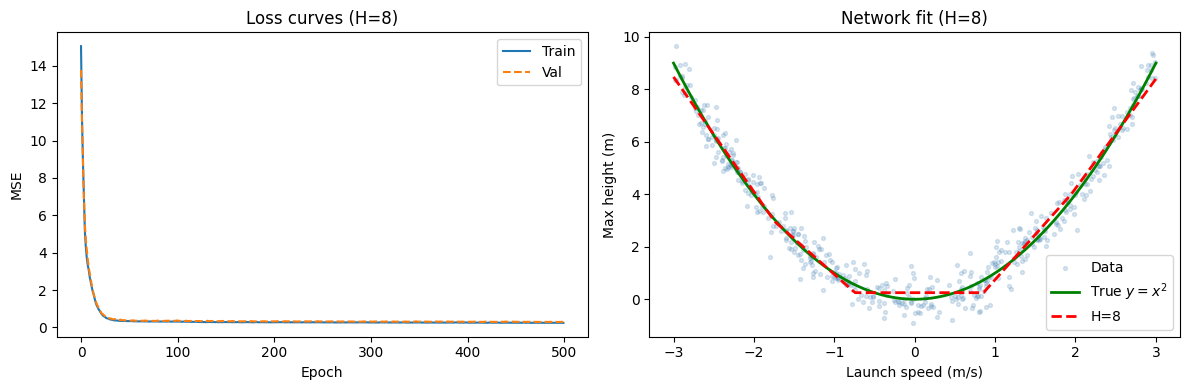

In [12]:
### SOLUTION — training function and run with H=8

def train_network3(x_tr, y_tr, x_v, y_v, H=8, lr=0.001, epochs=500, batch_size=32):
    W1, b1, w2, b2 = init_network3(H)
    train_ls, val_ls = [], []

    for epoch in range(epochs):
        perm = np.random.permutation(len(x_tr))
        xt   = x_tr[perm].reshape(-1, 1)
        yt   = y_tr[perm]

        bl = []
        for i in range(0, len(xt), batch_size):
            xb = xt[i : i + batch_size]
            yb = yt[i : i + batch_size]

            y_hat, cache = forward3(xb, W1, b1, w2, b2)
            bl.append(np.mean((y_hat - yb) ** 2))

            dW1, db1_, dw2, db2_ = backward3(y_hat, yb, cache, w2)
            W1 -= lr * dW1
            b1 -= lr * db1_
            w2 -= lr * dw2
            b2 -= lr * db2_

        train_ls.append(np.mean(bl))

        yv_hat, _ = forward3(x_v.reshape(-1, 1), W1, b1, w2, b2)
        val_ls.append(np.mean((yv_hat - y_v) ** 2))

    return W1, b1, w2, b2, train_ls, val_ls


# --- Split ---
split3 = int(0.8 * N3)
idx3   = np.random.permutation(N3)
x3_train, x3_val = x3[idx3[:split3]], x3[idx3[split3:]]
y3_train, y3_val = y3[idx3[:split3]], y3[idx3[split3:]]

# --- Train H=8 ---
np.random.seed(42)
W1_8, b1_8, w2_8, b2_8, train_ls3, val_ls3 = train_network3(
    x3_train, y3_train, x3_val, y3_val, H=8, lr=0.01, epochs=500
)
print(f"H=8  final val MSE: {val_ls3[-1]:.4f}")

x_line3 = np.linspace(-3, 3, 200)
y_pred3_8, _ = forward3(x_line3.reshape(-1, 1), W1_8, b1_8, w2_8, b2_8)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_ls3, label="Train")
plt.plot(val_ls3, label="Val", linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss curves (H=8)")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x3, y3, alpha=0.2, s=8, color='steelblue', label="Data")
plt.plot(x_line3, x_line3**2, color='green', linewidth=2, label="True $y=x^2$")
plt.plot(x_line3, y_pred3_8, color='red', linewidth=2, linestyle='--', label="H=8")
plt.xlabel("Launch speed (m/s)")
plt.ylabel("Max height (m)")
plt.title("Network fit (H=8)")
plt.legend()

plt.tight_layout()
plt.show()

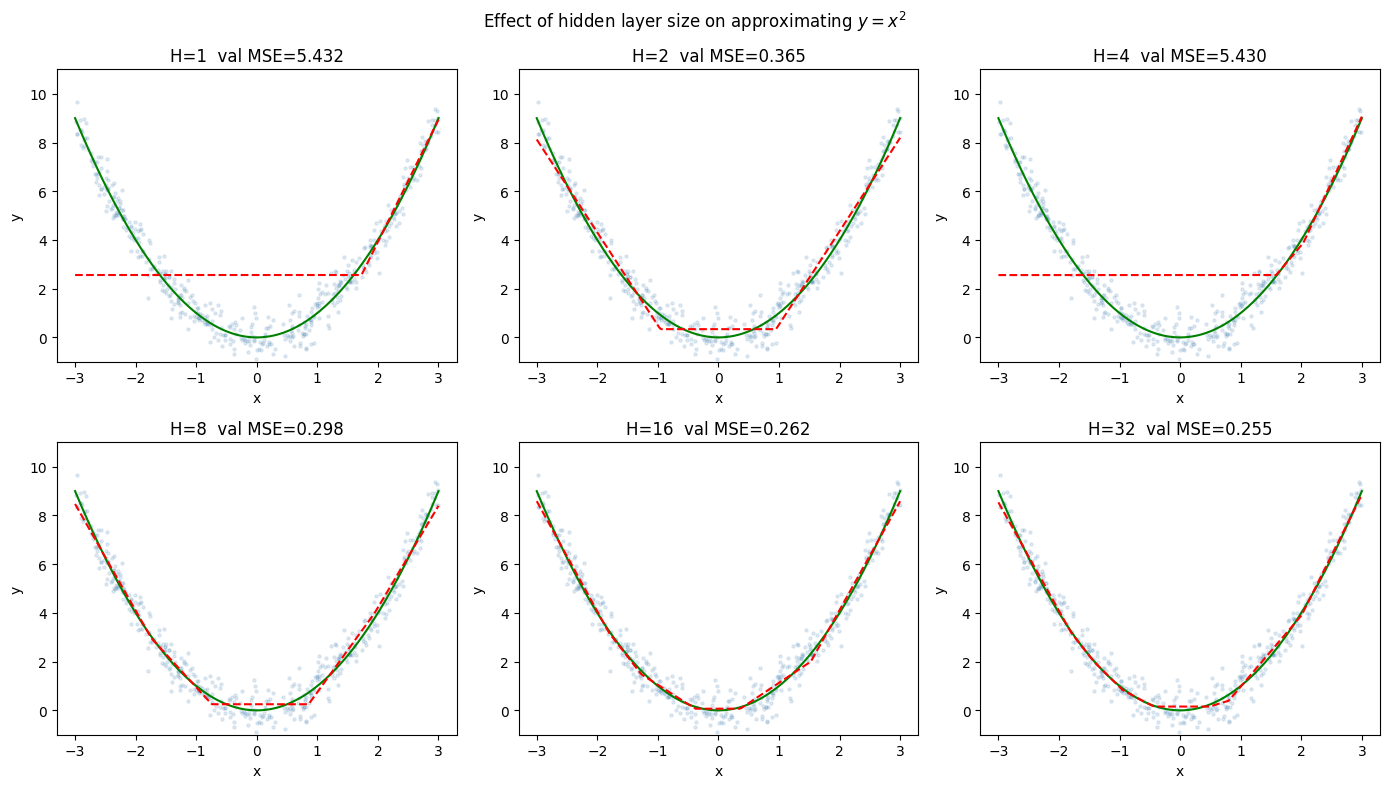

Note: H=1 can only produce a piecewise-linear function with one kink.
Approximating a smooth parabola requires several neurons to combine their
individual ReLU 'ramps' into a curved shape.


In [13]:
### SOLUTION — experiment: vary H

hidden_sizes3 = [1, 2, 4, 8, 16, 32]

plt.figure(figsize=(14, 8))

for k, H in enumerate(hidden_sizes3):
    np.random.seed(42)
    W1, b1, w2, b2, _, val_ls = train_network3(
        x3_train, y3_train, x3_val, y3_val, H=H, lr=0.01, epochs=500
    )
    y_pred, _ = forward3(x_line3.reshape(-1, 1), W1, b1, w2, b2)

    plt.subplot(2, 3, k + 1)
    plt.scatter(x3, y3, alpha=0.15, s=5, color='steelblue')
    plt.plot(x_line3, x_line3**2, color='green', linewidth=1.5)
    plt.plot(x_line3, y_pred, color='red', linewidth=1.5, linestyle='--')
    plt.title(f"H={H}  val MSE={val_ls[-1]:.3f}")
    plt.ylim(-1, 11)
    plt.xlabel("x")
    plt.ylabel("y")

plt.suptitle("Effect of hidden layer size on approximating $y = x^2$", fontsize=12)
plt.tight_layout()
plt.show()

print("Note: H=1 can only produce a piecewise-linear function with one kink.")
print("Approximating a smooth parabola requires several neurons to combine their")
print("individual ReLU 'ramps' into a curved shape.")

---
## Exercise 4 — Parabolic Trajectory with PyTorch

### Background
Implementing backpropagation by hand is valuable for understanding — but for deeper
networks it becomes tedious and error-prone. **PyTorch** solves this with
**automatic differentiation (autograd)**: you write only the forward pass,
call `.backward()`, and PyTorch computes all gradients by tracing the
computation graph automatically.

### Key patterns you will use
```python
optimizer.zero_grad()   # clear accumulated gradients from the previous step
loss.backward()         # compute all gradients via autograd
optimizer.step()        # apply the update rule
```

### Your Task

Re-implement the same $y = x^2$ regression using PyTorch:

1. Convert `x3_train, y3_train, x3_val, y3_val` to `torch.FloatTensor`.
   Use `.unsqueeze(1)` to turn shape `(N,)` into `(N, 1)`.

2. Define: `nn.Sequential(nn.Linear(1, H), nn.ReLU(), nn.Linear(H, 1))` with $H = 8$.

3. Use `nn.MSELoss()` and `optim.SGD(model.parameters(), lr=0.01)`.
   We use **SGD** here — same optimiser as the manual implementation in Exercise 3 —
   so the comparison is fair: same architecture, same update rule, same data.

4. Train for 500 epochs with `batch_size = 32`. The loss curves and predicted
   curves should closely match Exercise 3. If they do not, something is wrong in
   one of the two implementations.

5. In the final cell of this exercise, swap SGD for **Adam** and observe the
   difference. Why does Adam converge faster?

In [14]:
### SOLUTION — convert data to tensors and define model

x3_train_t = torch.FloatTensor(x3_train).unsqueeze(1)   # (400, 1)
y3_train_t = torch.FloatTensor(y3_train).unsqueeze(1)   # (400, 1)
x3_val_t   = torch.FloatTensor(x3_val).unsqueeze(1)
y3_val_t   = torch.FloatTensor(y3_val).unsqueeze(1)

print(f"Training tensor shape: {x3_train_t.shape}")

# Model: 1 -> 8 -> 1  (same architecture as Exercise 3)
H4 = 8
model4 = nn.Sequential(
    # add a linear layer (1 input, H4 outputs)
    # add a ReLU activation function
    # add a linear layer (H4 inputs, 1 output)
)

# create loss function
criterion4 = nn....() # look for
# SGD with the same lr as Exercise 3 — fair comparison
optimizer4 = optim...

print(f"\nModel architecture:")
print(model4)
total_params = sum(p.numel() for p in model4.parameters())
print(f"Total trainable parameters: {total_params}")

SyntaxError: invalid syntax (1914874527.py, line 19)

In [ ]:
### SOLUTION — training loop

epochs4 = ...
batch_size4 = ...
train_ls4, val_ls4 = [], []

for epoch in range(epochs4):
    model4.train()
    perm = torch.randperm(len(x3_train_t))
    bl = []

    for i in range(0, len(x3_train_t), batch_size4):
        idx_b = perm[i : i + batch_size4]
        xb = x3_train_t[idx_b]
        yb = y3_train_t[idx_b]

        optimizer4.zero_grad()         # 1. clear old gradients
        y_hat = model4(xb)             # 2. forward pass
        loss = criterion4(y_hat, yb)   # 3. compute loss
        loss.backward()                # 4. backprop (autograd)
        optimizer4.step()              # 5. update weights
        bl.append(loss.item())

    train_ls4.append(np.mean(bl))

    model4.eval()
    with torch.no_grad():
        val_pred = model4(x3_val_t)
        val_ls4.append(criterion4(val_pred, y3_val_t).item())

print(f"PyTorch final val MSE: {val_ls4[-1]:.4f}")
print(f"Manual  final val MSE: {val_ls3[-1]:.4f}")

In [ ]:
### SOLUTION — compare manual backprop vs PyTorch autograd (both SGD, H=8)

x_line3_t = torch.FloatTensor(x_line3).unsqueeze(1)
model4.eval()
with torch.no_grad():
    y_pred4_line = model4(x_line3_t).numpy().ravel()

# Re-train manual model with the same seed for a clean comparison
np.random.seed(42)
W1_cmp, b1_cmp, w2_cmp, b2_cmp, train_ls3_cmp, val_ls3_cmp = train_network3(
    x3_train, y3_train, x3_val, y3_val, H=8, lr=0.01, epochs=500
)
y_manual_line_cmp, _ = forward3(x_line3.reshape(-1, 1), W1_cmp, b1_cmp, w2_cmp, b2_cmp)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_ls4,       label="Train (PyTorch SGD)")
plt.plot(val_ls4,         label="Val (PyTorch SGD)",  linestyle="--")
plt.plot(train_ls3_cmp,   label="Train (Manual SGD)",  alpha=0.7)
plt.plot(val_ls3_cmp,     label="Val (Manual SGD)",    linestyle=":", alpha=0.7)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Loss: Manual SGD vs PyTorch SGD (H=8) — should match")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(x3, y3, alpha=0.15, s=8, color='steelblue', label="Data")
plt.plot(x_line3, x_line3**2,          color='green',  linewidth=2,              label="True")
plt.plot(x_line3, y_pred4_line,        color='red',    linewidth=2, linestyle='--', label="PyTorch SGD (H=8)")
plt.plot(x_line3, y_manual_line_cmp,   color='orange', linewidth=2, linestyle=':',  label="Manual  SGD (H=8)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Predicted curves — should overlap")
plt.legend()

plt.tight_layout()
plt.show()

print("\nIf the two curves closely overlap, it confirms that the manual backprop")
print("implementation is correct and equivalent to PyTorch's autograd.")
print(f"\nPyTorch SGD  final val MSE: {val_ls4[-1]:.4f}")
print(f"Manual  SGD  final val MSE: {val_ls3_cmp[-1]:.4f}")

In [ ]:
### SOLUTION — now use Adam and observe the difference

model4_adam = nn....


optimizer_adam = ...

train_ls_adam, val_ls_adam = [], []

for epoch in range(500):
    # loop for training.
    # do not forget flags, and clears

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_ls4,      label="Train SGD",  color='steelblue')
plt.plot(val_ls4,        label="Val SGD",    color='steelblue',  linestyle='--')
plt.plot(train_ls_adam,  label="Train Adam", color='tomato')
plt.plot(val_ls_adam,    label="Val Adam",   color='tomato',     linestyle='--')
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SGD vs Adam — same model, same data")
plt.legend()

plt.subplot(1, 2, 2)
model4_adam.eval()
with torch.no_grad():
    y_adam_line = model4_adam(x_line3_t).numpy().ravel()
plt.scatter(x3, y3, alpha=0.15, s=8, color='steelblue', label="Data")
plt.plot(x_line3, x_line3**2,       color='green',      linewidth=2,              label="True")
plt.plot(x_line3, y_pred4_line,     color='steelblue',  linewidth=2, linestyle='--', label="SGD")
plt.plot(x_line3, y_adam_line,      color='tomato',     linewidth=2, linestyle=':',  label="Adam")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Fit quality: SGD vs Adam")
plt.legend()
plt.tight_layout()
plt.show()

print(f"SGD  final val MSE: {val_ls4[-1]:.4f}")
print(f"Adam final val MSE: {val_ls_adam[-1]:.4f}")
print("\nAdam uses momentum and per-parameter adaptive learning rates — it typically")
print("converges faster and to a lower loss. From Exercise 5 onwards we use Adam.")

---
## Exercise 5 — Effect of Network Depth on Regression

### Background
In Exercise 4 you trained a **1-hidden-layer** network
(`Input → Linear(8) → ReLU → Linear(1)`) on the $y = x^2$ regression task.
Width (the number of neurons $H$ per layer) is one axis of network capacity —
but **depth** (the number of hidden layers) is another.

Deeper networks can, in principle, learn more complex hierarchical representations.
However, going too deep introduces challenges:
- **Vanishing gradients:** gradients shrink as they propagate through many layers,
  making early-layer weights hard to update.
- **Harder optimisation:** the loss landscape becomes more non-convex.
- **Diminishing returns:** beyond a certain depth, extra layers no longer reduce
  validation error — they may even slightly worsen it because the network has more
  parameters to tune but the task is not complex enough to need them.

### Your Task
We reuse the parabolic dataset from Exercise 4 (`x3_train_t`, `y3_train_t`,
`x3_val_t`, `y3_val_t`) and compare networks with **1 to 6 hidden layers**,
all with width $H = 8$, trained with **Adam** for 500 epochs.

1. Write a helper function `build_deep_model(n_hidden, H)` that returns an
   `nn.Sequential` with `n_hidden` hidden layers (each `Linear(H, H) → ReLU`),
   sandwiched between an input projection `Linear(1, H)` and an output head `Linear(H, 1)`.

2. Train one model for each depth in `[1, 2, 3, 4, 5, 6]`.  
   Record the **final validation MSE** for each depth.

3. Plot a line chart of **val MSE vs number of hidden layers**.  
   At what depth does the curve flatten? Does it worsen beyond that point?

4. On a single figure, overlay the **predicted curves** for all depths against the
   true $y = x^2$. Shallower networks may underfit; very deep ones may match
   moderate-depth ones (or slightly worsen if optimisation struggled).

5. **Reflection:** Why doesn't adding more layers always help here? Would your
   answer change if the target function were more complex (e.g. $y = \sin(10x)$)?


In [ ]:
### SOLUTION — depth study: 1–6 hidden layers on y=x²

def build_deep_model(n_hidden, H):
    """Return an nn.Sequential with n_hidden hidden layers of width H."""
    layers = [nn.Linear(1, H), nn.ReLU()]# create first layer
    # create rest if layers

    # create last layer
    return nn.Sequential(*layers)

# test several depths
depths      = [1, 2, 3, 4, 5, 6]
H_depth     = 8
epochs_depth     = 100
batch_size_depth = 32

depth_val_mse      = []
depth_models       = []
depth_train_curves = []
depth_val_curves   = []

torch.manual_seed(42)

for n_hidden in depths:
    # create model
    model_d     = ...
    # create optimizer
    optimizer_d = ...
    # create criterion
    criterion_d = ...
    tr_losses, vl_losses = [], []

    for epoch in range(epochs_depth):
        # training loop

    depth_val_mse.append(vl_losses[-1])
    depth_models.append(model_d)
    depth_train_curves.append(tr_losses)
    depth_val_curves.append(vl_losses)
    n_params = sum(p.numel() for p in model_d.parameters())
    print(f"  {n_hidden} hidden layer(s): tr MSE = {tr_losses[-1]:.4f}  val MSE = {vl_losses[-1]:.4f}  "
          f"|  params = {n_params}")


In [ ]:
### SOLUTION — plots: val MSE vs depth and predicted curves

cmap_depth = plt.cm.plasma

plt.figure(figsize=(12, 4))

# Left: MSE vs depth
plt.subplot(1, 2, 1)
plt.plot(depths, depth_val_mse, marker='o', color='steelblue', linewidth=2)
plt.xticks(depths)
plt.xlabel("Number of hidden layers")
plt.ylabel("Validation MSE")
plt.title("Regression error vs network depth (H=8, Adam, 500 epochs)")
for d, mse in zip(depths, depth_val_mse):
    plt.annotate(f"{mse:.3f}", (d, mse), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=9)

# Right: predicted curves
plt.subplot(1, 2, 2)
plt.scatter(x3, y3, alpha=0.1, s=8, color='grey', label="Data")
plt.plot(x_line3, x_line3**2, color='black', linewidth=2, label="True $y=x^2$")
for i, (n_hidden, model_d) in enumerate(zip(depths, depth_models)):
    model_d.eval()
    with torch.no_grad():
        y_pred_d = model_d(x_line3_t).numpy().ravel()
    c = cmap_depth(i / (len(depths) - 1))
    plt.plot(x_line3, y_pred_d, color=c, linewidth=1.5, linestyle='--',
             label=f"{n_hidden} layer(s) (MSE={depth_val_mse[i]:.3f})")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Predicted curves for each depth")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Validation loss curves over training
plt.figure(figsize=(8, 4))
for i, n_hidden in enumerate(depths):
    c = cmap_depth(i / (len(depths) - 1))
    plt.plot(depth_val_curves[i], color=c, label=f"{n_hidden} layer(s)")
plt.xlabel("Epoch")
plt.ylabel("Validation MSE")
plt.title("Validation loss curves — each depth")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

best_depth = depths[int(np.argmin(depth_val_mse))]
print(f"Best depth: {best_depth} hidden layer(s)  "
      f"→  val MSE = {min(depth_val_mse):.4f}")
print()
print("Observation: for a smooth curve like y=x², 1–2 hidden layers already capture")
print("most of the structure. Deeper networks have the same representational capacity")
print("here but are harder to optimise, so they often converge to similar or slightly")
print("worse solutions within the same number of epochs.")


---
## Exercise 6 — Robot Locomotion Mode Classification (Multi-class, PyTorch)

### Background
An IMU (inertial measurement unit) on a robot records two quantities at each timestep:
- $a$: linear acceleration magnitude (m/s²)
- $\omega$: angular velocity magnitude (rad/s)

We want to classify the robot's locomotion mode into **three states**:
- **0 — Stationary:** low $a$, low $\omega$
- **1 — Walking straight:** moderate $a$, low $\omega$
- **2 — Turning:** moderate $a$, high $\omega$

### Network
$$\text{Input}(2) \to \text{Linear}(H) \to \text{ReLU} \to \text{Linear}(3) \to [\text{CrossEntropyLoss}]$$

**Softmax** converts raw scores (logits) to probabilities summing to 1.
**Cross-entropy loss** measures how well those probabilities match the true one-hot label.

> **Common bug:** `nn.CrossEntropyLoss` applies softmax *internally*. Do **not** add
> a softmax layer before it — you would be applying softmax twice.
>
> Labels passed to `CrossEntropyLoss` must be `torch.long` (integer class indices),
> **not** one-hot vectors.

In [ ]:
n6 = 200   # samples per class

# Class 0: Stationary
c6_0 = np.random.randn(n6, 2) * 0.3 + np.array([0.5, 0.3])
# Class 1: Walking straight
c6_1 = np.random.randn(n6, 2) * 0.4 + np.array([1.7, 0.5])
# Class 2: Turning
c6_2 = np.random.randn(n6, 2) * 0.4 + np.array([1.1, 1.5])

X6 = np.vstack([c6_0, c6_1, c6_2]).astype(np.float32)
Y6 = np.array([0]*n6 + [1]*n6 + [2]*n6)

colors6 = ['steelblue', 'seagreen', 'tomato']
labels6 = ['Stationary', 'Walking', 'Turning']

plt.figure(figsize=(6, 5))
for cls in range(3):
    m = Y6 == cls
    plt.scatter(X6[m, 0], X6[m, 1], alpha=0.5, s=15, color=colors6[cls], label=labels6[cls])
plt.xlabel("Acceleration (m/s²)")
plt.ylabel("Angular velocity (rad/s)")
plt.title("IMU data — Robot locomotion modes")
plt.legend()
plt.tight_layout()
plt.show()

### Your Task

1. **Split** `X6, Y6` into train/val (80/20). Convert to tensors — labels must be
   `torch.LongTensor`.

2. **Define** a network: `Linear(2, H) → ReLU → Linear(H, 3)`. Choose $H$ yourself
   (start with 16).

3. **Train** with `nn.CrossEntropyLoss` and `optim.Adam`. Track loss *and* accuracy
   on both train and val sets each epoch.

4. **Evaluate:**
   - Overall accuracy and per-class accuracy on the val set
   - Confusion matrix (rows = true label, columns = predicted label)
   - Decision boundary plot (same meshgrid trick as Exercise 2)

5. **Experiments — try at least two:**
   - Change $H \in \{4, 8, 16, 32, 64\}$
   - Add a second hidden layer — does it help?
   - Swap `Adam` for `SGD` — how does training stability change?
   - Insert `nn.Dropout(0.2)` after the ReLU — what happens to val accuracy?
   - Increase the noise in the data generation cell above and re-run — at what noise
     level does the classifier start making systematic errors?

In [ ]:
### SOLUTION — split, convert, define model

split6 = int(0.8 * len(X6))
idx6   = np.random.permutation(len(X6))
X6_train, X6_val = X6[idx6[:split6]], X6[idx6[split6:]]
Y6_train, Y6_val = Y6[idx6[:split6]], Y6[idx6[split6:]]


X6_train_t = torch.FloatTensor(X6_train)
Y6_train_t = torch.LongTensor(Y6_train)    # <-- must be Long for CrossEntropyLoss
X6_val_t   = torch.FloatTensor(X6_val)
Y6_val_t   = torch.LongTensor(Y6_val)

# create model
H6 = 16
model6 = nn.Sequential(
    nn.Linear(2, H6),
    nn.ReLU(),
    ...# linear, pay attention to number ouf outputs you need for CE loss
)

# CE loss
criterion6 = ...

# Optimizer
optimizer6 = ...

print(model6)

In [ ]:
### SOLUTION — training loop

epochs6 = 300
batch_size6 = 32
train_ls6, val_ls6 = [], []
train_acc6, val_acc6 = [], []

for epoch in range(epochs6):
    #train loop
    model6.train()
    perm = torch.randperm(len(X6_train_t))
    bl = []

    for i in range(0, len(X6_train_t), batch_size6):
        idx_b = perm[i : i + batch_size6]
        xb = X6_train_t[idx_b]
        yb = Y6_train_t[idx_b]

        # reset grads
        ...
        # compute logits
        ...
        # compute loss
        ...
        # back-propagaate
        ...
        # step
        ...

        bl.append(loss.item())

    train_ls6.append(np.mean(bl))

    model6.eval()
    with torch.no_grad():
        # evaluation -> yields logits
        tr_logits = model6(X6_train_t)
        # compute prediction by taking the maximum logits
        tr_preds  = tr_logits.argmax(dim=1)
        # accuracy
        train_acc6.append((tr_preds == Y6_train_t).float().mean().item())

        # evaluation
        val_logits = ...
        # loss
        val_ls6.append(...)
        # prediction
        val_preds  = ...
        # accuracy
        val_acc6.append(...)

print(f"Final train accuracy: {train_acc6[-1]*100:.1f}%")
print(f"Final val   accuracy: {val_acc6[-1]*100:.1f}%")

In [ ]:
### SOLUTION — loss and accuracy curves

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_ls6, label="Train loss")
plt.plot(val_ls6,   label="Val loss",  linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title(f"Training curves (H={H6})")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot([a * 100 for a in train_acc6], label="Train acc")
plt.plot([a * 100 for a in val_acc6],   label="Val acc",   linestyle="--")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy over training")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
### SOLUTION — confusion matrix

model6.eval()
with torch.no_grad():
    final_preds6 = model6(X6_val_t).argmax(dim=1).numpy()

cm6 = confusion_matrix(Y6_val, final_preds6)

print("Confusion matrix (rows = true label, columns = predicted label):")
print(f"{'':14}", end="")
for lbl in labels6:
    print(f"{lbl:>12}", end="")
print()
for i, lbl in enumerate(labels6):
    print(f"{lbl:14}", end="")
    for j in range(3):
        print(f"{cm6[i, j]:>12}", end="")
    print()

plt.figure(figsize=(5, 4))
plt.imshow(cm6, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1, 2], labels6, rotation=15)
plt.yticks([0, 1, 2], labels6)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
for i in range(3):
    for j in range(3):
        color = 'white' if cm6[i, j] > cm6.max() / 2 else 'black'
        plt.text(j, i, str(cm6[i, j]), ha='center', va='center', fontsize=14, color=color)
plt.tight_layout()
plt.show()

print("\nPer-class accuracy on validation set:")
for cls in range(3):
    mask = Y6_val == cls
    acc  = (final_preds6[mask] == cls).mean()
    print(f"  {labels6[cls]:15}: {acc*100:.1f}%")

In [ ]:
### SOLUTION — decision regions

xmin6 = X6[:, 0].min() - 0.3
xmax6 = X6[:, 0].max() + 0.3
ymin6 = X6[:, 1].min() - 0.3
ymax6 = X6[:, 1].max() + 0.3

xx6, yy6 = np.meshgrid(np.linspace(xmin6, xmax6, 300),
                        np.linspace(ymin6, ymax6, 300))
grid6 = torch.FloatTensor(np.c_[xx6.ravel(), yy6.ravel()])

model6.eval()
with torch.no_grad():
    Z6 = model6(grid6).argmax(dim=1).numpy().reshape(xx6.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx6, yy6, Z6, alpha=0.25, cmap='tab10', levels=[-0.5, 0.5, 1.5, 2.5])
for cls in range(3):
    m = Y6 == cls
    plt.scatter(X6[m, 0], X6[m, 1], s=15, alpha=0.6, color=colors6[cls], label=labels6[cls])
plt.xlabel("Acceleration (m/s²)")
plt.ylabel("Angular velocity (rad/s)")
plt.title(f"Decision regions — H={H6}")
plt.legend()
plt.tight_layout()
plt.show()

---
## Exercise 7 — Effect of Network Depth on Classification

### Background
Exercise 5 showed that for the simple $y = x^2$ regression task, adding hidden
layers beyond 1–2 brings little benefit and can even slightly hurt — the function
is smooth and low-dimensional, so shallow networks already capture it well.

Classification tasks tell a richer story because we can **visualise the decision
boundary** directly. Deeper networks can carve out more complex, non-linear regions
in the input space. But past a certain depth, two new problems emerge:

- **Over-segmentation:** the network fits the training set so well that its
  boundaries become jagged and generalisation to the val set suffers.
- **Optimisation failure:** very deep networks suffer from vanishing gradients —
  gradients shrink exponentially as they pass through many layers, so early
  layers barely update. Loss curves stall or diverge.

A standard remedy is **Batch Normalisation** (`nn.BatchNorm1d`): it rescales each
layer's activations to zero mean and unit variance before the next layer, keeping
gradients healthy across depth.

### Your Task
Use the IMU dataset from Exercise 6 (`X6_train_t`, `Y6_train_t`, etc.).
All networks use $H = 16$ neurons per hidden layer and are trained with **Adam**
for 300 epochs.

1. **Reuse** `build_deep_model(n_hidden, H)` from Exercise 5 — but adapt it for
   3-class classification: input dimension 2, output dimension 3.
   Write `build_clf_model(n_hidden, H)` that does this.

2. **Train** models with `n_hidden ∈ {1, 2, 3, 4, 5, 6, 7, 8}` hidden layers.
   Record final **val accuracy** and **val loss** for each depth.

3. **Plot** val accuracy vs depth.  
   At what depth does accuracy peak? What happens beyond that?

4. **Visualise decision boundaries** for depths 1, 3, 5, 8 on a 2×2 grid of
   subplots. Observe how boundaries evolve from simple to complex (and possibly
   fragmented for very deep networks).

5. **Compare training stability:** plot the val-loss training curves for all depths
   on a single axes. Which depths show stable convergence? Which ones oscillate or
   plateau early?

6. **(Bonus)** Add `nn.BatchNorm1d(H)` after each ReLU and re-run the deepest
   model (`n_hidden = 8`). Does it converge more reliably?


In [ ]:
### SOLUTION — build classifier of variable depth and train 1–8 layers

def build_clf_model(n_hidden, H, use_bn=False):
    """n_hidden hidden layers of width H; input=2, output=3."""
    ...

depths7      = [1, 2, 3, 4, 5, 6, 7, 8]
H7           = 16
epochs7      = 300
batch_size7  = 32

d7_val_acc    = []
d7_val_loss   = []
d7_models     = []
d7_val_curves = []

torch.manual_seed(42)
criterion7 = nn.CrossEntropyLoss()

for n_hidden in depths7:
    # create model and optimizer

    for epoch in range(epochs7):
        # train model
        model7.train()
        perm = torch.randperm(len(X6_train_t))

        for i in range(0, len(X6_train_t), batch_size7):
          ...
        model7.eval()
        with torch.no_grad():
            ...

    # final eval after full train
    model7.eval()
    with torch.no_grad():
        ...

    d7_val_acc.append(acc7)
    d7_val_loss.append(vl_losses7[-1])
    d7_models.append(model7)
    d7_val_curves.append(vl_losses7)
    n_params7 = sum(p.numel() for p in model7.parameters())
    print(f"  {n_hidden} hidden layer(s): val acc = {acc7*100:.1f}%  "
          f"|  val loss = {vl_losses7[-1]:.4f}  |  params = {n_params7}")


In [ ]:
### SOLUTION — accuracy vs depth + decision boundaries

# Accuracy vs depth
plt.figure(figsize=(8, 4))
plt.plot(depths7, [a * 100 for a in d7_val_acc],
         marker='o', color='steelblue', linewidth=2)
plt.xticks(depths7)
plt.xlabel("Number of hidden layers")
plt.ylabel("Validation accuracy (%)")
plt.title("Classification accuracy vs network depth (H=16, Adam, 300 epochs)")
for d, a in zip(depths7, d7_val_acc):
    plt.annotate(f"{a*100:.1f}%", (d, a * 100),
                 textcoords="offset points", xytext=(0, 8),
                 ha='center', fontsize=9)
plt.tight_layout()
plt.show()

# Decision boundaries for depths 1, 3, 5, 8
show_depths = [1, 3, 5, 8]
show_models = [d7_models[depths7.index(d)] for d in show_depths]

xmin7 = X6[:, 0].min() - 0.3;  xmax7 = X6[:, 0].max() + 0.3
ymin7 = X6[:, 1].min() - 0.3;  ymax7 = X6[:, 1].max() + 0.3
xx7, yy7 = np.meshgrid(np.linspace(xmin7, xmax7, 300),
                        np.linspace(ymin7, ymax7, 300))
grid7 = torch.FloatTensor(np.c_[xx7.ravel(), yy7.ravel()])

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, n_hidden, mdl in zip(axes, show_depths, show_models):
    mdl.eval()
    with torch.no_grad():
        Z7 = mdl(grid7).argmax(dim=1).numpy().reshape(xx7.shape)
    ax.contourf(xx7, yy7, Z7, alpha=0.25, cmap='tab10',
                levels=[-0.5, 0.5, 1.5, 2.5])
    for cls in range(3):
        m = Y6 == cls
        ax.scatter(X6[m, 0], X6[m, 1], s=12, alpha=0.6,
                   color=colors6[cls], label=labels6[cls])
    val_acc_d = d7_val_acc[depths7.index(n_hidden)]
    ax.set_title(f"{n_hidden} layer(s)\nacc={val_acc_d*100:.1f}%")
    ax.set_xlabel("Acceleration (m/s²)")
axes[0].set_ylabel("Angular velocity (rad/s)")
axes[0].legend(fontsize=8)
plt.suptitle("Decision boundaries at selected depths", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
### SOLUTION — training stability and bonus: BatchNorm on deepest model

# Val-loss curves for all depths
cmap7 = plt.cm.viridis
plt.figure(figsize=(9, 4))
for i, n_hidden in enumerate(depths7):
    c = cmap7(i / (len(depths7) - 1))
    plt.plot(d7_val_curves[i], color=c, label=f"{n_hidden} layer(s)")
plt.xlabel("Epoch")
plt.ylabel("Validation loss (cross-entropy)")
plt.title("Training stability: val loss curves for each depth")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Bonus: BatchNorm on n_hidden=8
print("=" * 55)
print("Bonus: n_hidden=8 with BatchNorm vs without BatchNorm")
print("=" * 55)

torch.manual_seed(42)
model7_bn  = build_clf_model(8, H7, use_bn=True)
opt7_bn    = optim.Adam(model7_bn.parameters(), lr=0.01)
vl_bn      = []

for epoch in range(epochs7):
    model7_bn.train()
    perm = torch.randperm(len(X6_train_t))
    for i in range(0, len(X6_train_t), batch_size7):
        idx_b = perm[i : i + batch_size7]
        xb, yb = X6_train_t[idx_b], Y6_train_t[idx_b]
        opt7_bn.zero_grad()
        criterion7(model7_bn(xb), yb).backward()
        opt7_bn.step()
    model7_bn.eval()
    with torch.no_grad():
        vl_bn.append(criterion7(model7_bn(X6_val_t), Y6_val_t).item())

model7_bn.eval()
with torch.no_grad():
    acc_bn = (model7_bn(X6_val_t).argmax(1) == Y6_val_t).float().mean().item()

plt.figure(figsize=(8, 4))
plt.plot(d7_val_curves[depths7.index(8)], label="8 layers — no BN",  color='tomato')
plt.plot(vl_bn,                           label="8 layers — with BN", color='steelblue')
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("8 hidden layers: effect of Batch Normalisation")
plt.legend()
plt.tight_layout()
plt.show()

print(f"8-layer no BN  — val acc: {d7_val_acc[depths7.index(8)]*100:.1f}%")
print(f"8-layer with BN — val acc: {acc_bn*100:.1f}%")
print()
print("Observation: BatchNorm keeps activations well-scaled at every layer,")
print("which stabilises gradients and typically allows deeper networks to")
print("converge faster and to a better solution.")
